In [2]:
def plot_metrics_seaborn(folder_paths, output_filename='metrics_comparison_seaborn_h.png',
                         method_colors=None):
    import pandas as pd
    import numpy as np
    import os
    import matplotlib as mpl
    import matplotlib.pyplot as plt
    import seaborn as sns

    mpl.rcParams['pdf.fonttype'] = 42
    mpl.rcParams['ps.fonttype'] = 42
    mpl.rcParams['svg.fonttype'] = 'none'
    mpl.rcParams['text.usetex'] = False
    if isinstance(folder_paths, list):
        folder_dict = {os.path.basename(path): path for path in folder_paths}
    else:
        folder_dict = folder_paths

    metrics_list = ['accuracy', 'f1_macro', 'f1_weighted', 'precision', 'recall', 'ECS', 'ARI', 'AMI', 'AvgBIO']

    long_rows, acc_map = [], {}
    for method, folder_path in folder_dict.items():
        csv_path = os.path.join(folder_path, 'metrics_results.csv')
        if not os.path.exists(csv_path):
            print(f"[MISS] {method}: {csv_path} 不存在")
            continue
        try:
            df = pd.read_csv(csv_path)
            if len(df) == 0:
                print(f"[EMPTY] {method}: {csv_path} 无数据")
                continue
            row = df.iloc[0].to_dict()
            acc_map[method] = float(row.get('accuracy', float('-inf')))
            for m in metrics_list:
                if m in row and pd.notna(row[m]):
                    long_rows.append({'Method': method, 'Metric': m, 'Value': float(row[m])})
        except Exception as e:
            print(f"[READ ERR] {method}: {e}")

    plot_df = pd.DataFrame(long_rows)
    if plot_df.empty:
        print("No data to plot")
        return plot_df
    methods_in_data = plot_df['Method'].unique().tolist()
    method_order = sorted(methods_in_data, key=lambda m: acc_map.get(m, float('-inf')), reverse=True)
    plot_df['Metric'] = pd.Categorical(plot_df['Metric'], categories=metrics_list, ordered=True)
    default_colors = [
        '#1f77b4', '#ff7f0e', '#1b9e77', '#d62728', '#9467bd', "#9edae5", "#c49c94","#A6D854",
        '#8c564b', '#e377c2', '#7f7f7f', '#bcbd22', '#17becf', '#393b79', '#000000', '#ad494a'
    ]
    method_colors = method_colors or {}
    palette = {}
    used = set()
    for m, c in method_colors.items():
        if m in methods_in_data and isinstance(c, str):
            palette[m] = c
            used.add(c.lower())

    missing = [m for m in method_order if m not in method_colors]
    print("Missing colors for methods:", missing)
    print("Provided colors:", len(method_colors))

    available = [c for c in default_colors if c.lower() not in used]
    ai = 0
    for m in method_order:
        if m not in palette:
            palette[m] = available[ai % len(available)]
            ai += 1
    # ============================================================
    plt.figure(figsize=(16, 22))
    ax = sns.barplot(
        data=plot_df,
        x='Value', y='Metric',
        hue='Method',
        hue_order=method_order,  
        palette=palette,
        orient='h',
        width=0.9
    )
    for container in ax.containers:
        ax.bar_label(container, fmt='%.3f', padding=2, fontsize=8)
    title_fs, axis_label_fs, tick_fs = 18, 14, 14
    plt.title('Metrics Comparison Across Different Methods (Axolotl brain regeneration)',
              fontsize=title_fs, fontweight='bold')
    plt.xlabel('Values', fontsize=axis_label_fs)
    plt.ylabel('Metrics', fontsize=axis_label_fs)
    ax.tick_params(axis='both', labelsize=tick_fs)
    plt.grid(True, alpha=0.3, axis='x')
    plt.legend(title='Methods', bbox_to_anchor=(1.02, 1), loc='upper left')
    plt.tight_layout()
    #plt.savefig(output_filename, dpi=300, bbox_inches='tight')
    plt.savefig('/maiziezhou_lab2/yuling/MouseSpinal/label_transfer/metric/regeneration/metrics_comparison.pdf',
            bbox_inches='tight')

    plt.show()
    rank_df = (pd.Series(acc_map, name='accuracy')
               .loc[method_order]
               .reset_index().rename(columns={'index': 'Method'}))
    print("\n[Method order by accuracy (desc)]")
    print(rank_df.to_string(index=False, float_format='%.4f'))

    return plot_df


Missing colors for methods: []
Provided colors: 21


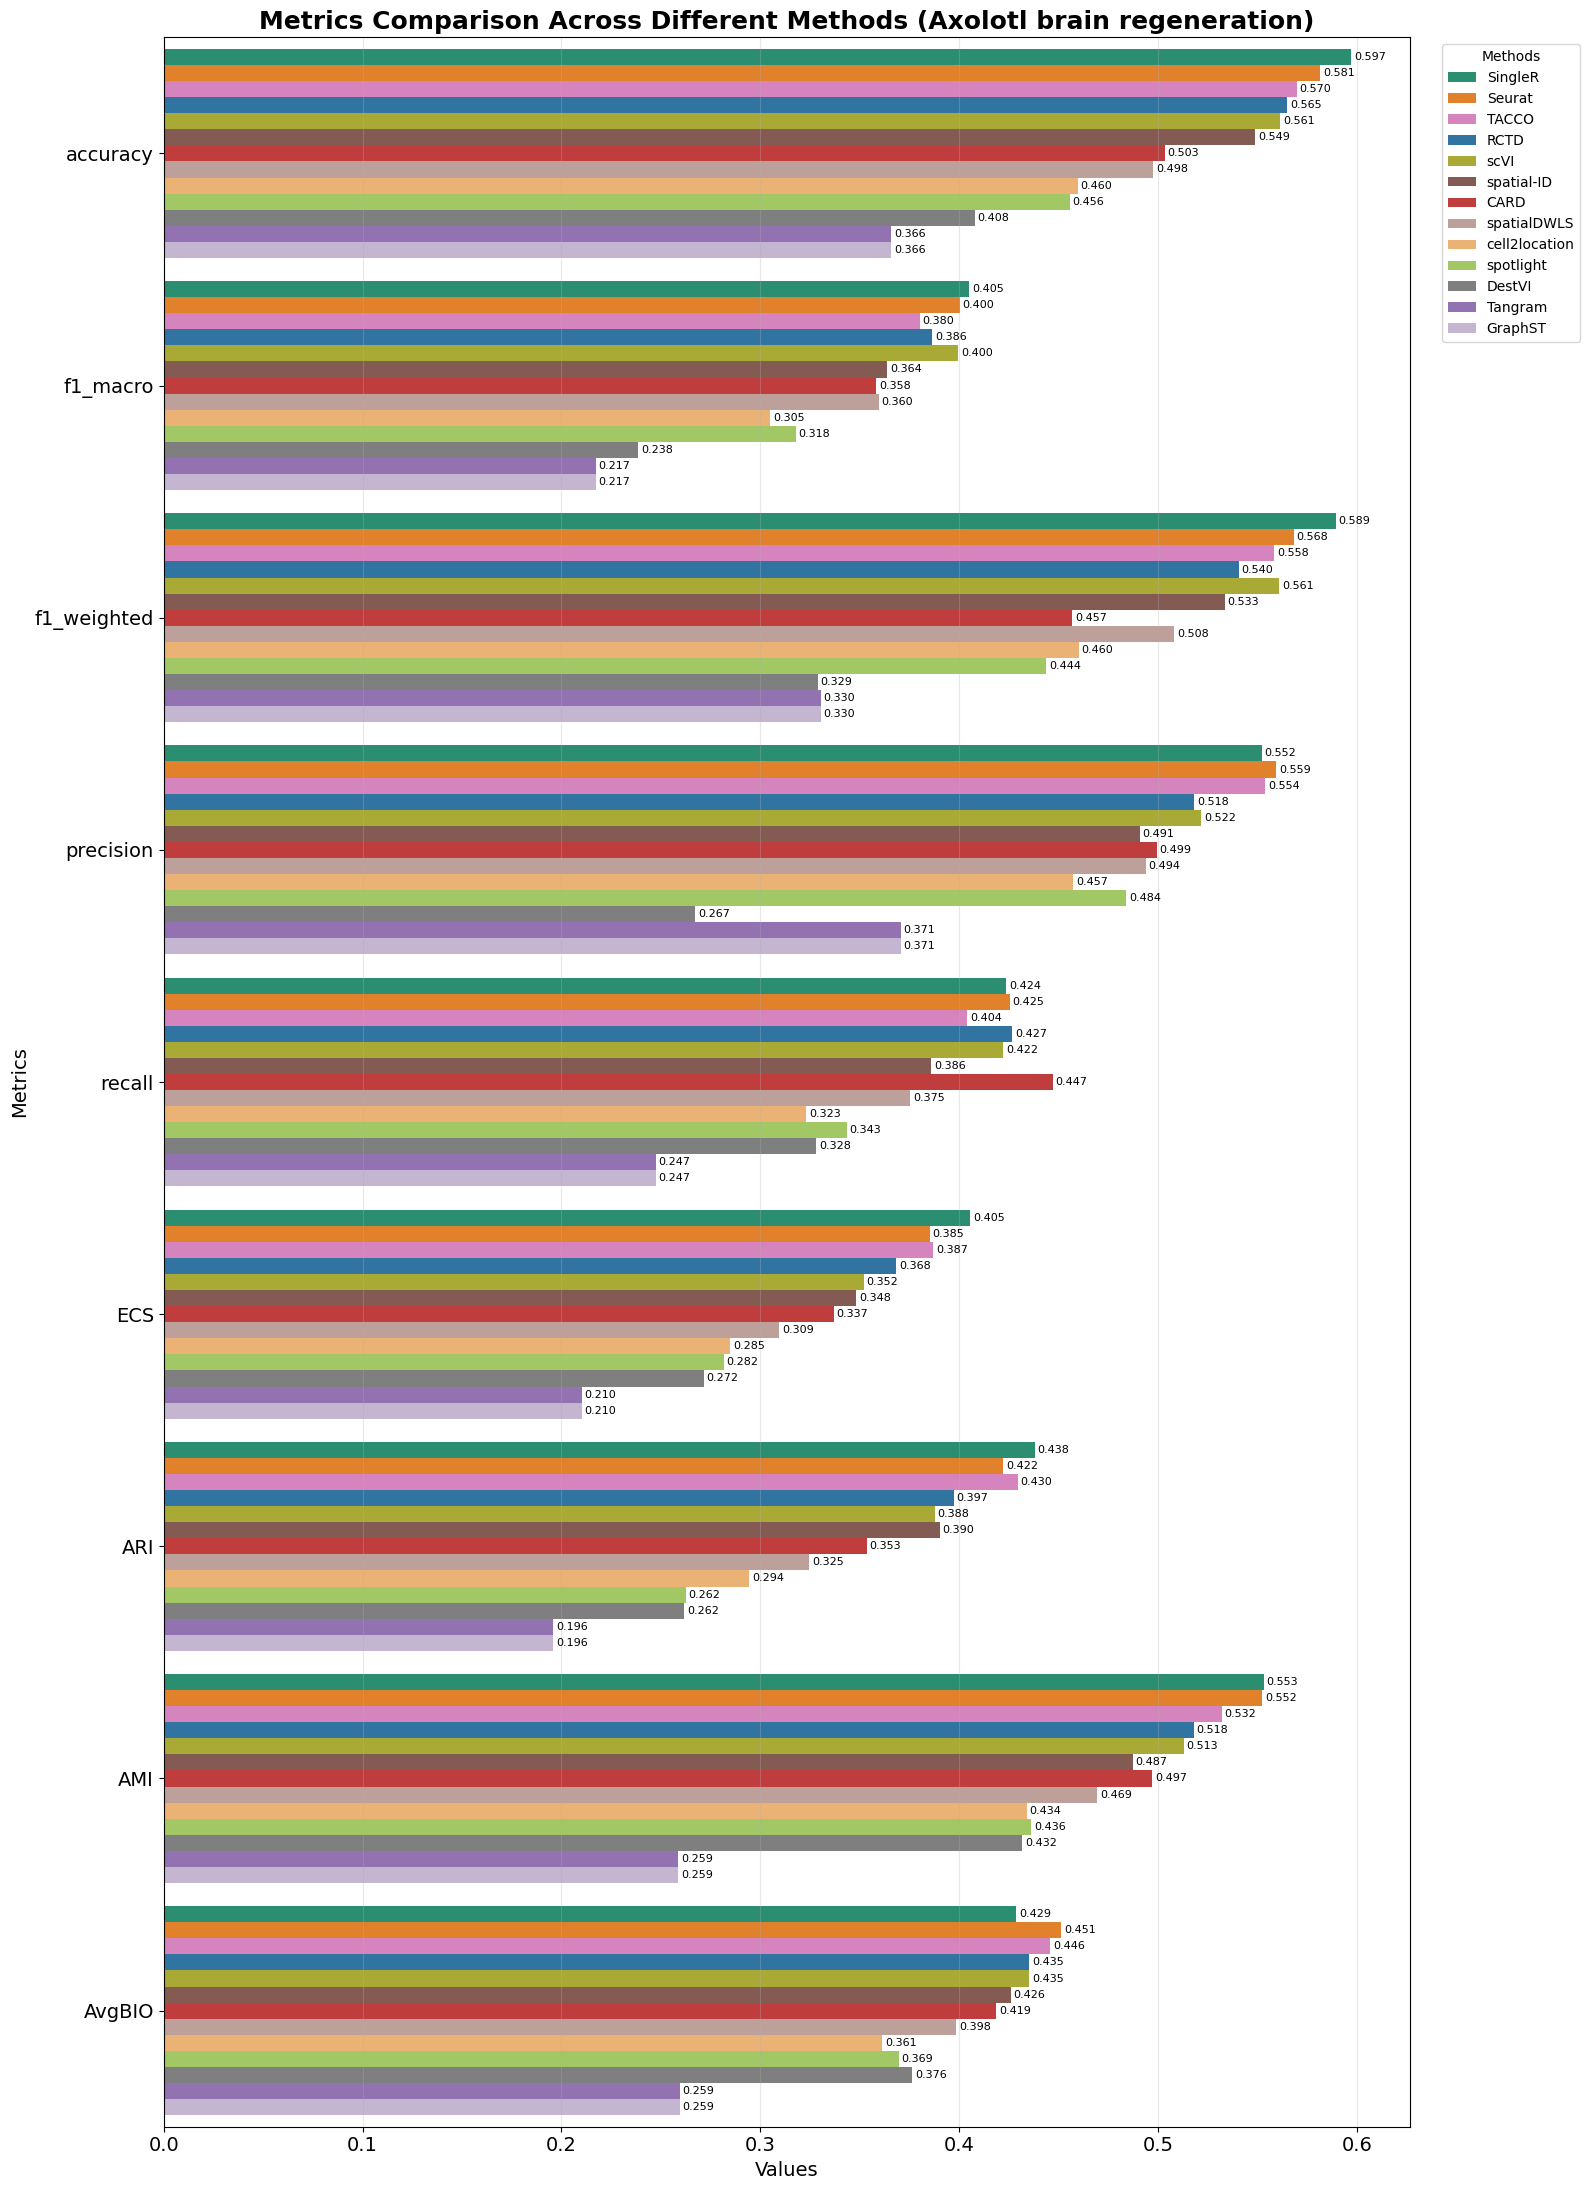


[Method order by accuracy (desc)]
       Method  accuracy
      SingleR    0.5970
       Seurat    0.5815
        TACCO    0.5698
         RCTD    0.5649
         scVI    0.5614
   spatial-ID    0.5489
         CARD    0.5033
  spatialDWLS    0.4976
cell2location    0.4595
    spotlight    0.4557
       DestVI    0.4079
      Tangram    0.3659
      GraphST    0.3659


In [ ]:
 
if __name__ == "__main__":
   # 'scGPT - (linear probing)': '/maiziezhou_lab2/yuling/MouseSpinal/label_transfer/scGPT/HumanLymph_linear_probing',  
    folders_dict = {
        'RCTD': '/maiziezhou_lab2/yuling/MouseSpinal/label_transfer/RCTD/regeneration_output',
        'Seurat': '/maiziezhou_lab2/yuling/MouseSpinal/label_transfer/Seurat/regeneration_output',
        'SingleR': '/maiziezhou_lab2/yuling/MouseSpinal/label_transfer/SingleR/regeneration_output',
        'CARD': '/maiziezhou_lab2/yuling/MouseSpinal/label_transfer/CARD/regeneration_output',
        'Tangram': '/maiziezhou_lab2/yuling/MouseSpinal/label_transfer/Tangram/regeneration_output',
        'cell2location': '/maiziezhou_lab2/yuling/MouseSpinal/label_transfer/cell2location/regeneration_output',
        'spatialDWLS': '/maiziezhou_lab2/yuling/MouseSpinal/label_transfer/spatialDWLS/regeneration_output',
        'spotlight': '/maiziezhou_lab2/yuling/MouseSpinal/label_transfer/spotlight/regeneration_output',
        'spatial-ID': '/maiziezhou_lab2/yuling/MouseSpinal/label_transfer/spatialID/regeneration_output',
        'TACCO': '/maiziezhou_lab2/yuling/MouseSpinal/label_transfer/tacco/regeneration_output',
        'DestVI': '/maiziezhou_lab2/yuling/MouseSpinal/label_transfer/DestVI/regeneration_output',
        'scVI': '/maiziezhou_lab2/yuling/MouseSpinal/label_transfer/scVI/regeneration_output',
        #'scGPT - (reference mapping)': '/maiziezhou_lab2/yuling/MouseSpinal/label_transfer/scGPT/HumanLymph_reference_mapping',
        #'scGPT - (partial fine tuning)': '/maiziezhou_lab2/yuling/MouseSpinal/label_transfer/scGPT/HumanLymph',
        #'scGPT - (linear probing)': '/maiziezhou_lab2/yuling/MouseSpinal/label_transfer/scGPT/HumanLymph_linear_probing',
        #'scCello - (linear probing)': '/maiziezhou_lab2/yuling/MouseSpinal/label_transfer/scCello/linear_probing',
        #'scCello - (partial fine tuning)': '/maiziezhou_lab2/yuling/MouseSpinal/label_transfer/scCello/partial_fine_tune',
        'GraphST' : '/maiziezhou_lab2/yuling/MouseSpinal/label_transfer/GraphST/regeneration_output',
        #'Nicheformer - (linear probing)' : '/maiziezhou_lab2/yuling/MouseSpinal/label_transfer/Nicheformer/linearProbing',
        #'Nicheformer - (partial fine tuning)': '/maiziezhou_lab2/yuling/MouseSpinal/label_transfer/Nicheformer/partialFineTune',
        #'SToFM - (partial fine tuning)': '/maiziezhou_lab2/yuling/MouseSpinal/label_transfer/SToFM/linearProbing'
    }
    
    # results = plot_metrics_from_folders(folders_dict)
    my_colors = {
        "CARD": "#d62728",
        "cell2location": "#fdb462",   # ColorBrewer Pastel
        "DestVI": "#7f7f7f",
        "GraphST": "#c5b0d5",
        "RCTD": "#1f77b4",
        "scVI": "#bcbd22",
        "Seurat": "#ff7f0e",
        "SingleR": "#1b9e77",
        "spatialDWLS": "#c49c94",
        "spatial-ID": "#8c564b",
        "spotlight": "#A6D854",
        "TACCO": "#e377c2",
        "Tangram": "#9467bd",
        'scGPT - (reference mapping)': '#17becf',
        'scGPT - (partial fine tuning)': '#393b79',
        'scCello - (linear probing)' : '#000000',
        'scCello - (partial fine tuning)': '#ad494a',
        "scGPT - (linear probing)": "#2ca02c",        # muted green
        "Nicheformer - (linear probing)": "#8dd3c7",
        "Nicheformer - (partial fine tuning)": "#4b0082",
        "SToFM - (partial fine tuning)":"#00BFC4"
    }

    results = plot_metrics_seaborn(folders_dict, method_colors=my_colors)


# development axolotl

In [1]:
def plot_metrics_seaborn(folder_paths, output_filename='metrics_comparison_seaborn_h.png',
                         method_colors=None):
    import pandas as pd
    import numpy as np
    import os
    import matplotlib as mpl
    import matplotlib.pyplot as plt
    import seaborn as sns

    mpl.rcParams['pdf.fonttype'] = 42
    mpl.rcParams['ps.fonttype'] = 42
    mpl.rcParams['svg.fonttype'] = 'none'
    mpl.rcParams['text.usetex'] = False
    if isinstance(folder_paths, list):
        folder_dict = {os.path.basename(path): path for path in folder_paths}
    else:
        folder_dict = folder_paths

    metrics_list = ['accuracy', 'f1_macro', 'f1_weighted', 'precision', 'recall', 'ECS', 'ARI', 'AMI', 'AvgBIO']

    long_rows, acc_map = [], {}
    for method, folder_path in folder_dict.items():
        csv_path = os.path.join(folder_path, 'metrics_results.csv')
        if not os.path.exists(csv_path):
            print(f"[MISS] {method}: {csv_path} 不存在")
            continue
        try:
            df = pd.read_csv(csv_path)
            if len(df) == 0:
                print(f"[EMPTY] {method}: {csv_path} 无数据")
                continue
            row = df.iloc[0].to_dict()
            acc_map[method] = float(row.get('accuracy', float('-inf')))
            for m in metrics_list:
                if m in row and pd.notna(row[m]):
                    long_rows.append({'Method': method, 'Metric': m, 'Value': float(row[m])})
        except Exception as e:
            print(f"[READ ERR] {method}: {e}")

    plot_df = pd.DataFrame(long_rows)
    if plot_df.empty:
        print("No data to plot")
        return plot_df
    methods_in_data = plot_df['Method'].unique().tolist()
    method_order = sorted(methods_in_data, key=lambda m: acc_map.get(m, float('-inf')), reverse=True)
    plot_df['Metric'] = pd.Categorical(plot_df['Metric'], categories=metrics_list, ordered=True)
    default_colors = [
        '#1f77b4', '#ff7f0e', '#1b9e77', '#d62728', '#9467bd', "#9edae5", "#c49c94","#A6D854",
        '#8c564b', '#e377c2', '#7f7f7f', '#bcbd22', '#17becf', '#393b79', '#000000', '#ad494a'
    ]
    method_colors = method_colors or {}
    palette = {}
    used = set()
    for m, c in method_colors.items():
        if m in methods_in_data and isinstance(c, str):
            palette[m] = c
            used.add(c.lower())

    missing = [m for m in method_order if m not in method_colors]
    print("Missing colors for methods:", missing)
    print("Provided colors:", len(method_colors))

    available = [c for c in default_colors if c.lower() not in used]
    ai = 0
    for m in method_order:
        if m not in palette:
            palette[m] = available[ai % len(available)]
            ai += 1
    # ============================================================
    plt.figure(figsize=(16, 22))
    ax = sns.barplot(
        data=plot_df,
        x='Value', y='Metric',
        hue='Method',
        hue_order=method_order,  
        palette=palette,
        orient='h',
        width=0.9
    )
    for container in ax.containers:
        ax.bar_label(container, fmt='%.3f', padding=2, fontsize=8)
    title_fs, axis_label_fs, tick_fs = 18, 14, 14
    plt.title('Metrics Comparison Across Different Methods (Axolotl brain development)',
              fontsize=title_fs, fontweight='bold')
    plt.xlabel('Values', fontsize=axis_label_fs)
    plt.ylabel('Metrics', fontsize=axis_label_fs)
    ax.tick_params(axis='both', labelsize=tick_fs)
    plt.grid(True, alpha=0.3, axis='x')
    plt.legend(title='Methods', bbox_to_anchor=(1.02, 1), loc='upper left')
    plt.tight_layout()
    #plt.savefig(output_filename, dpi=300, bbox_inches='tight')
    plt.savefig('/maiziezhou_lab2/yuling/MouseSpinal/label_transfer/metric/Develop/metrics_comparison.pdf',
            bbox_inches='tight')

    plt.show()
    rank_df = (pd.Series(acc_map, name='accuracy')
               .loc[method_order]
               .reset_index().rename(columns={'index': 'Method'}))
    print("\n[Method order by accuracy (desc)]")
    print(rank_df.to_string(index=False, float_format='%.4f'))

    return plot_df


Missing colors for methods: []
Provided colors: 21


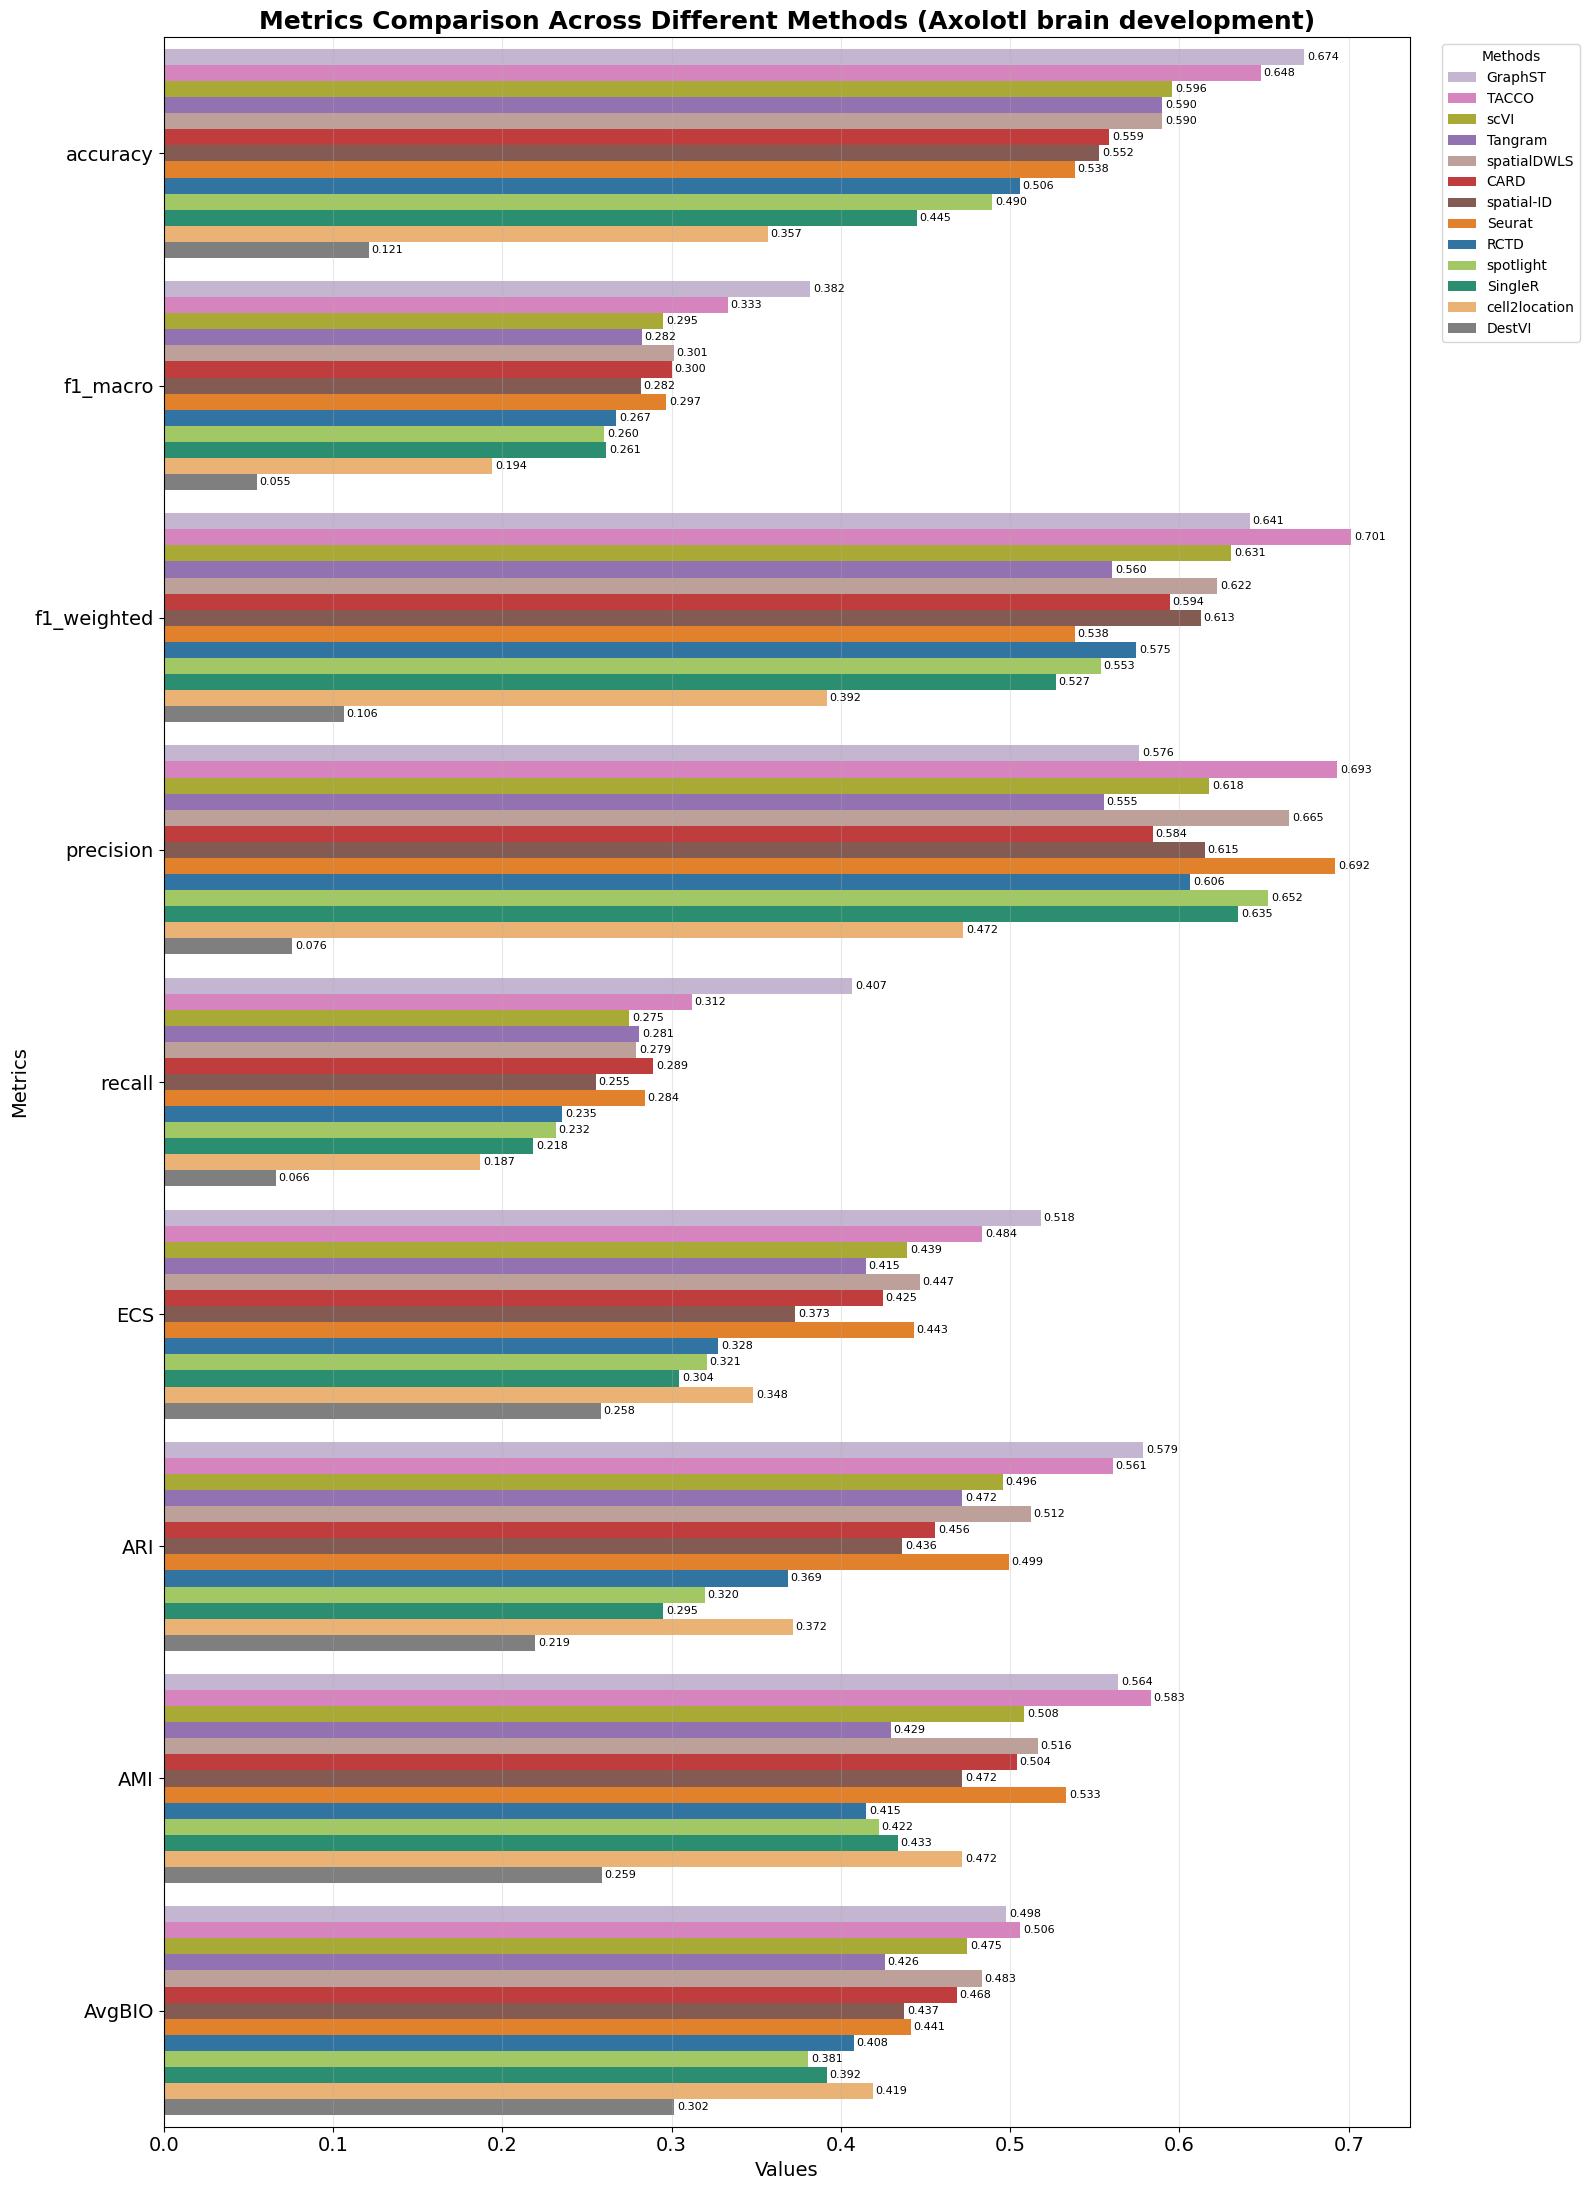


[Method order by accuracy (desc)]
       Method  accuracy
      GraphST    0.6737
        TACCO    0.6479
         scVI    0.5958
      Tangram    0.5897
  spatialDWLS    0.5897
         CARD    0.5586
   spatial-ID    0.5525
       Seurat    0.5383
         RCTD    0.5058
    spotlight    0.4895
      SingleR    0.4448
cell2location    0.3568
       DestVI    0.1212


In [2]:
 
if __name__ == "__main__":
   # 'scGPT - (linear probing)': '/maiziezhou_lab2/yuling/MouseSpinal/label_transfer/scGPT/HumanLymph_linear_probing',  
    folders_dict = {
        'RCTD': '/maiziezhou_lab2/yuling/MouseSpinal/label_transfer/RCTD/Development_output',
        'Seurat': '/maiziezhou_lab2/yuling/MouseSpinal/label_transfer/Seurat/Development_output',
        'SingleR': '/maiziezhou_lab2/yuling/MouseSpinal/label_transfer/SingleR/Development_output',
        'CARD': '/maiziezhou_lab2/yuling/MouseSpinal/label_transfer/CARD/Development_output',
        'Tangram': '/maiziezhou_lab2/yuling/MouseSpinal/label_transfer/Tangram/Development_output',
        'cell2location': '/maiziezhou_lab2/yuling/MouseSpinal/label_transfer/cell2location/Development_output',
        'spatialDWLS': '/maiziezhou_lab2/yuling/MouseSpinal/label_transfer/spatialDWLS/Development_output',
        'spotlight': '/maiziezhou_lab2/yuling/MouseSpinal/label_transfer/spotlight/Development_output',
        'spatial-ID': '/maiziezhou_lab2/yuling/MouseSpinal/label_transfer/spatialID/Development_output',
        'TACCO': '/maiziezhou_lab2/yuling/MouseSpinal/label_transfer/tacco/Development_output',
        'DestVI': '/maiziezhou_lab2/yuling/MouseSpinal/label_transfer/DestVI/Development_output',
        'scVI': '/maiziezhou_lab2/yuling/MouseSpinal/label_transfer/scVI/Development_output',
        #'scGPT - (reference mapping)': '/maiziezhou_lab2/yuling/MouseSpinal/label_transfer/scGPT/HumanLymph_reference_mapping',
        #'scGPT - (partial fine tuning)': '/maiziezhou_lab2/yuling/MouseSpinal/label_transfer/scGPT/HumanLymph',
        #'scGPT - (linear probing)': '/maiziezhou_lab2/yuling/MouseSpinal/label_transfer/scGPT/HumanLymph_linear_probing',
        #'scCello - (linear probing)': '/maiziezhou_lab2/yuling/MouseSpinal/label_transfer/scCello/linear_probing',
        #'scCello - (partial fine tuning)': '/maiziezhou_lab2/yuling/MouseSpinal/label_transfer/scCello/partial_fine_tune',
        'GraphST' : '/maiziezhou_lab2/yuling/MouseSpinal/label_transfer/GraphST/Development_output',
        #'Nicheformer - (linear probing)' : '/maiziezhou_lab2/yuling/MouseSpinal/label_transfer/Nicheformer/linearProbing',
        #'Nicheformer - (partial fine tuning)': '/maiziezhou_lab2/yuling/MouseSpinal/label_transfer/Nicheformer/partialFineTune',
        #'SToFM - (partial fine tuning)': '/maiziezhou_lab2/yuling/MouseSpinal/label_transfer/SToFM/linearProbing'
    }
    
    # results = plot_metrics_from_folders(folders_dict)
    my_colors = {
        "CARD": "#d62728",
        "cell2location": "#fdb462",   # ColorBrewer Pastel
        "DestVI": "#7f7f7f",
        "GraphST": "#c5b0d5",
        "RCTD": "#1f77b4",
        "scVI": "#bcbd22",
        "Seurat": "#ff7f0e",
        "SingleR": "#1b9e77",
        "spatialDWLS": "#c49c94",
        "spatial-ID": "#8c564b",
        "spotlight": "#A6D854",
        "TACCO": "#e377c2",
        "Tangram": "#9467bd",
        'scGPT - (reference mapping)': '#17becf',
        'scGPT - (partial fine tuning)': '#393b79',
        'scCello - (linear probing)' : '#000000',
        'scCello - (partial fine tuning)': '#ad494a',
        "scGPT - (linear probing)": "#2ca02c",        # muted green
        "Nicheformer - (linear probing)": "#8dd3c7",
        "Nicheformer - (partial fine tuning)": "#4b0082",
        "SToFM - (partial fine tuning)":"#00BFC4"
    }

    results = plot_metrics_seaborn(folders_dict, method_colors=my_colors)


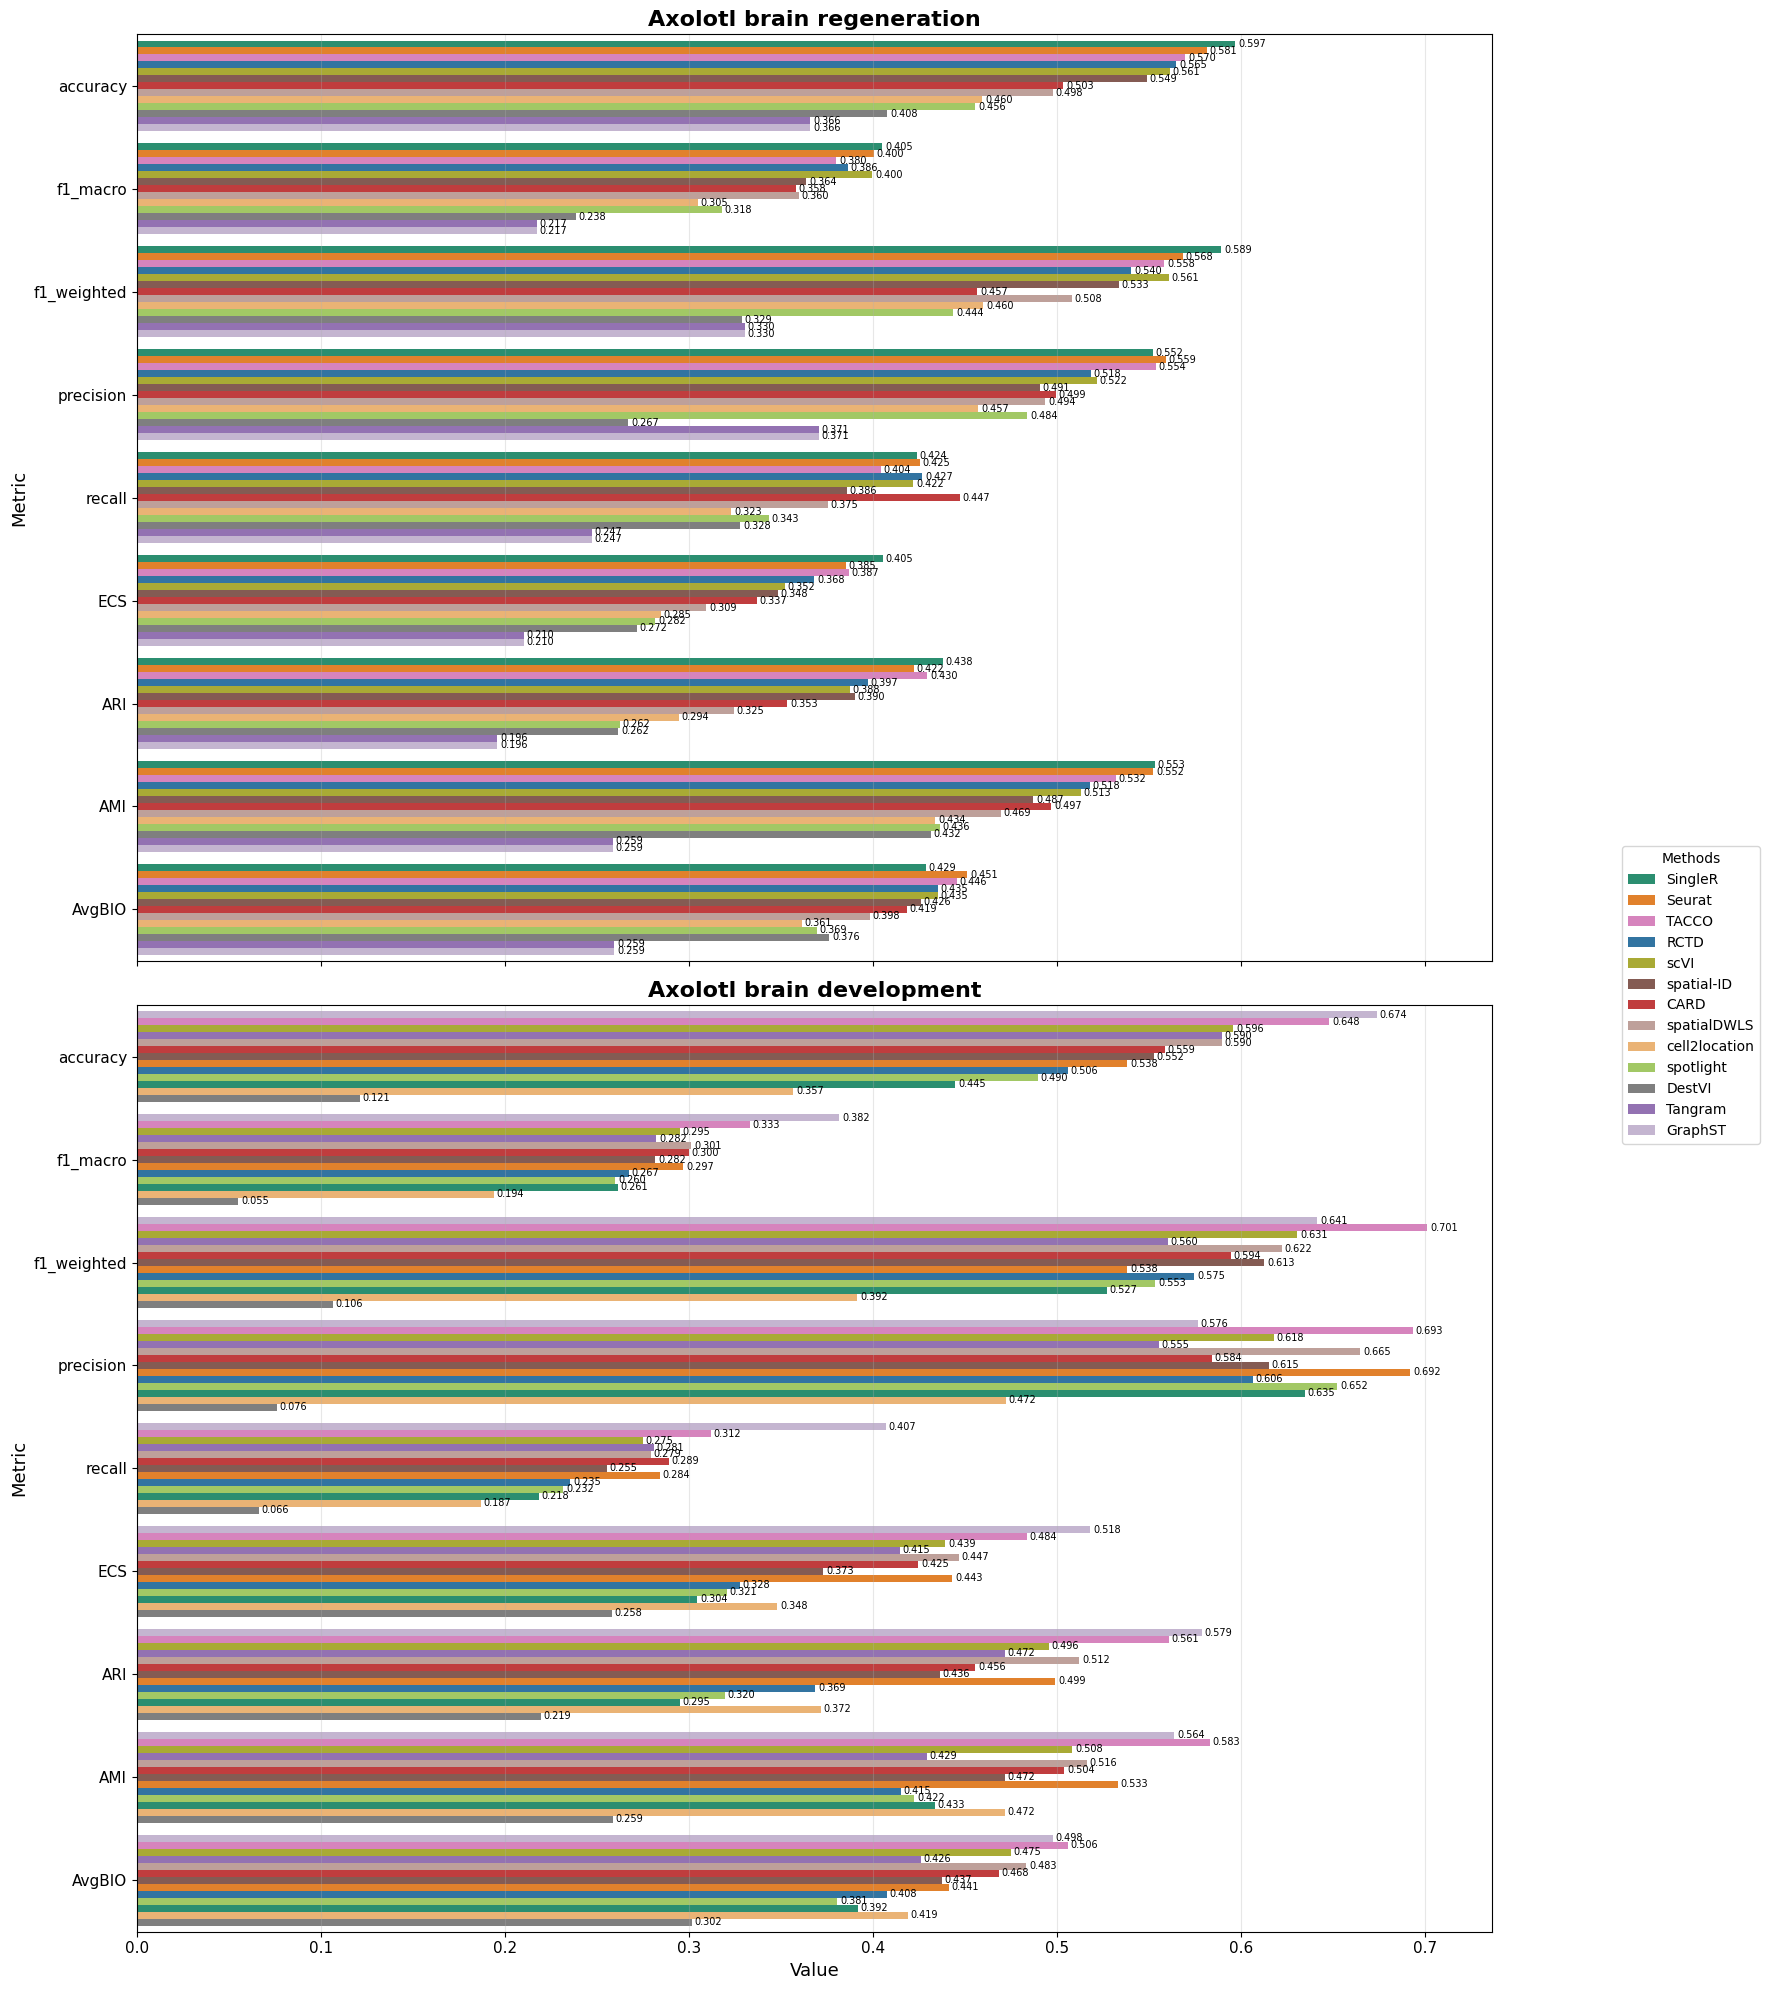

Saved: /maiziezhou_lab2/yuling/MouseSpinal/label_transfer/metric/metrics_comparison_1x2.pdf


In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns

mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42
mpl.rcParams['svg.fonttype'] = 'none'
mpl.rcParams['text.usetex'] = False

metrics_list = ['accuracy', 'f1_macro', 'f1_weighted', 'precision', 'recall', 'ECS', 'ARI', 'AMI', 'AvgBIO']

def collect_plot_df(folder_dict):
    long_rows, acc_map = [], {}
    for method, folder_path in folder_dict.items():
        csv_path = os.path.join(folder_path, 'metrics_results.csv')
        if not os.path.exists(csv_path):
            print(f"[MISS] {method}: {csv_path}")
            continue
        try:
            df = pd.read_csv(csv_path)
            if len(df) == 0:
                print(f"[EMPTY] {method}: {csv_path}")
                continue
            row = df.iloc[0].to_dict()
            acc_map[method] = float(row.get('accuracy', float('-inf')))
            for m in metrics_list:
                if m in row and pd.notna(row[m]):
                    long_rows.append({'Method': method, 'Metric': m, 'Value': float(row[m])})
        except Exception as e:
            print(f"[READ ERR] {method}: {e}")

    plot_df = pd.DataFrame(long_rows)
    if plot_df.empty:
        return plot_df, []

    methods_in_data = plot_df['Method'].unique().tolist()
    method_order = sorted(methods_in_data, key=lambda m: acc_map.get(m, float('-inf')), reverse=True)
    plot_df['Metric'] = pd.Categorical(plot_df['Metric'], categories=metrics_list, ordered=True)
    return plot_df, method_order

folders_regen = {
    'RCTD': '/maiziezhou_lab2/yuling/MouseSpinal/label_transfer/RCTD/regeneration_output',
    'Seurat': '/maiziezhou_lab2/yuling/MouseSpinal/label_transfer/Seurat/regeneration_output',
    'SingleR': '/maiziezhou_lab2/yuling/MouseSpinal/label_transfer/SingleR/regeneration_output',
    'CARD': '/maiziezhou_lab2/yuling/MouseSpinal/label_transfer/CARD/regeneration_output',
    'Tangram': '/maiziezhou_lab2/yuling/MouseSpinal/label_transfer/Tangram/regeneration_output',
    'cell2location': '/maiziezhou_lab2/yuling/MouseSpinal/label_transfer/cell2location/regeneration_output',
    'spatialDWLS': '/maiziezhou_lab2/yuling/MouseSpinal/label_transfer/spatialDWLS/regeneration_output',
    'spotlight': '/maiziezhou_lab2/yuling/MouseSpinal/label_transfer/spotlight/regeneration_output',
    'spatial-ID': '/maiziezhou_lab2/yuling/MouseSpinal/label_transfer/spatialID/regeneration_output',
    'TACCO': '/maiziezhou_lab2/yuling/MouseSpinal/label_transfer/tacco/regeneration_output',
    'DestVI': '/maiziezhou_lab2/yuling/MouseSpinal/label_transfer/DestVI/regeneration_output',
    'scVI': '/maiziezhou_lab2/yuling/MouseSpinal/label_transfer/scVI/regeneration_output',
    'GraphST': '/maiziezhou_lab2/yuling/MouseSpinal/label_transfer/GraphST/regeneration_output',
}

folders_develop = {
    'RCTD': '/maiziezhou_lab2/yuling/MouseSpinal/label_transfer/RCTD/Development_output',
    'Seurat': '/maiziezhou_lab2/yuling/MouseSpinal/label_transfer/Seurat/Development_output',
    'SingleR': '/maiziezhou_lab2/yuling/MouseSpinal/label_transfer/SingleR/Development_output',
    'CARD': '/maiziezhou_lab2/yuling/MouseSpinal/label_transfer/CARD/Development_output',
    'Tangram': '/maiziezhou_lab2/yuling/MouseSpinal/label_transfer/Tangram/Development_output',
    'cell2location': '/maiziezhou_lab2/yuling/MouseSpinal/label_transfer/cell2location/Development_output',
    'spatialDWLS': '/maiziezhou_lab2/yuling/MouseSpinal/label_transfer/spatialDWLS/Development_output',
    'spotlight': '/maiziezhou_lab2/yuling/MouseSpinal/label_transfer/spotlight/Development_output',
    'spatial-ID': '/maiziezhou_lab2/yuling/MouseSpinal/label_transfer/spatialID/Development_output',
    'TACCO': '/maiziezhou_lab2/yuling/MouseSpinal/label_transfer/tacco/Development_output',
    'DestVI': '/maiziezhou_lab2/yuling/MouseSpinal/label_transfer/DestVI/Development_output',
    'scVI': '/maiziezhou_lab2/yuling/MouseSpinal/label_transfer/scVI/Development_output',
    'GraphST': '/maiziezhou_lab2/yuling/MouseSpinal/label_transfer/GraphST/Development_output',
}

my_colors = {
    'CARD': '#d62728',
    'cell2location': '#fdb462',
    'DestVI': '#7f7f7f',
    'GraphST': '#c5b0d5',
    'RCTD': '#1f77b4',
    'scVI': '#bcbd22',
    'Seurat': '#ff7f0e',
    'SingleR': '#1b9e77',
    'spatialDWLS': '#c49c94',
    'spatial-ID': '#8c564b',
    'spotlight': '#A6D854',
    'TACCO': '#e377c2',
    'Tangram': '#9467bd',
}

plot_df_regen, order_regen = collect_plot_df(folders_regen)
plot_df_dev, order_dev = collect_plot_df(folders_develop)

fig, axes = plt.subplots(2, 1, figsize=(18, 20), sharex=False)

for ax, plot_df, order, title in [
    (axes[0], plot_df_regen, order_regen, 'Axolotl brain regeneration'),
    (axes[1], plot_df_dev, order_dev, 'Axolotl brain development'),
]:
    if plot_df.empty:
        ax.text(0.5, 0.5, 'No data', ha='center', va='center', fontsize=14)
        ax.axis('off')
        continue

    sns.barplot(
        data=plot_df,
        x='Value', y='Metric',
        hue='Method',
        hue_order=order,
        palette=my_colors,
        orient='h',
        width=0.88,
        ax=ax,
    )
    for container in ax.containers:
        ax.bar_label(container, fmt='%.3f', padding=2, fontsize=7)

    ax.set_title(title, fontsize=16, fontweight='bold')
    ax.set_xlabel('Value', fontsize=13)
    ax.set_ylabel('Metric', fontsize=13)
    ax.tick_params(axis='both', labelsize=11)
    ax.grid(True, alpha=0.3, axis='x')
    # Keep only a single legend for the whole figure
    if ax.get_legend() is not None:
        ax.get_legend().remove()

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, title='Methods', loc='center left', bbox_to_anchor=(0.96, 0.5), fontsize=10)

# Leave more left margin and keep plots visually centered.
plt.tight_layout(rect=[0.06, 0, 0.90, 1])
out_combined = '/maiziezhou_lab2/yuling/MouseSpinal/label_transfer/metric/metrics_comparison_1x2.pdf'
plt.savefig(out_combined, bbox_inches='tight')
plt.show()
print('Saved:', out_combined)